<a href="https://colab.research.google.com/github/AndrewUwU/EQ-Activiades-IARN/blob/main/AF5_Procesamiento_de_datos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**AF5_Procesamiento_de_datos**

**Hora clase:** N4

**Nombres:**
*   Andrés Esteban Eufraga Mejía  2021759

*   Alondra Isabella Quintero Lucio 2049693

*   Alan Tomás García García  2095422

*   Jorge Elí Casas Cortés 1993951

*   Angel Aldair Villalpando Reyes  2010651


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

In [ ]:
dataset = "https://raw.githubusercontent.com/dilp90/InteligenciaArtificial_y_RedesNeuronales_UANL_FIME/main/MachineLearning/Datasets/robot_sensors.csv"

In [ ]:
#Lectura del dataset
df = pd.read_csv(dataset)

In [ ]:
#Ver primeras filas
display(df.head())

,Tiempo (s),Distancia (cm),Velocidad (cm/s),Temperatura (°C)
0,0,43.708611,9.256646,23.925585
1,1,95.564288,27.095047,23.704682
2,2,75.879455,43.647292,33.593819
3,3,63.879264,36.611244,23.743193
4,4,24.041678,40.328057,24.079246


In [ ]:
#Borrar filas con datos nulos
df_limpio = df.dropna()

In [ ]:
#Filtrar valores atipicos
df_limpio = df_limpio[df_limpio['Velocidad (cm/s)'] >= 0]
df_limpio = df_limpio[df_limpio['Distancia (cm)'] >= 0]

# Comparación

In [ ]:
#Dataset original
print(f"Filas originales: {len(df)}")

Filas originales: 1000


In [ ]:
#Dataset filtrado y limpio
print(f"Filas limpias: {len(df_limpio)}")

Filas limpias: 913


# Normalización

In [ ]:
# Escalador Min-Max (transforma los valores a un rango de 0 a 1)
scaler = MinMaxScaler()

In [ ]:
#Aplicamos normalización y reconstruimos el dataset
columnas = df_limpio.columns
datos_escalados = scaler.fit_transform(df_limpio)

In [ ]:
#Creamos el nuevo dataframe con los datos normalizados
df_normalizado = pd.DataFrame(datos_escalados, columns=columnas)

In [ ]:
#Visualizamos las primeras filas
display(df_normalizado.head())

,Tiempo (s),Distancia (cm),Velocidad (cm/s),Temperatura (°C)
0,0.000000,0.371735,0.182609,0.262269
1,0.001001,0.950755,0.540740,0.247509
2,0.002002,0.730954,0.873049,0.908233
3,0.003003,0.596960,0.731791,0.250082
4,0.004004,0.152134,0.806411,0.272535


# Matplot

In [ ]:
#Ajustamos la figura
plt.figure(figsize=(20, 6))

<Figure size 2000x600 with 0 Axes>

<Figure size 2000x600 with 0 Axes>

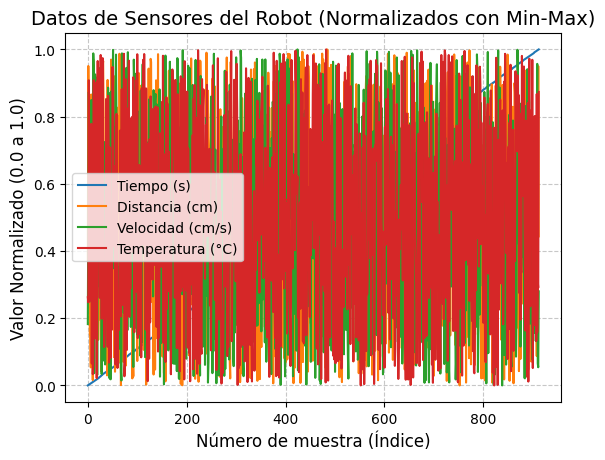

In [ ]:
#Graficamos
for columna in df_normalizado.columns:
    plt.plot(df_normalizado.index, df_normalizado[columna], label=columna, linewidth=1.5)

#Añadimos titulos, leyendas, etiquetas
plt.title('Datos de Sensores del Robot (Normalizados con Min-Max)', fontsize=14)
plt.xlabel('Número de muestra (Índice)', fontsize=12)
plt.ylabel('Valor Normalizado (0.0 a 1.0)', fontsize=12)
plt.legend(loc='best') # Mostrar la leyenda en la mejor posición!!!
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()